<a href="https://colab.research.google.com/github/Lochan-01/ml/blob/main/RL_Project_CartPole.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install gymnasium stable-baselines3 matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 4.7 MB/s eta 0:00:00


In [2]:
import gymnasium as gym
from stable_baselines3 import PPO
import matplotlib.pyplot as plt
import numpy as np

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [3]:
env = gym.make("CartPole-v1")

print("Observation Space:", env.observation_space)
print("Action Space:", env.action_space)

Observation Space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action Space: Discrete(2)


In [4]:
learning_rate = 0.0003
gamma = 0.99

model = PPO(
    "MlpPolicy",
    env,
    learning_rate=learning_rate,
    gamma=gamma,
    verbose=1
)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [5]:
model.learn(total_timesteps=10000)

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 20.8     |
|    ep_rew_mean     | 20.8     |
| time/              |          |
|    fps             | 1942     |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 26.6        |
|    ep_rew_mean          | 26.6        |
| time/                   |             |
|    fps                  | 1481        |
|    iterations           | 2           |
|    time_elapsed         | 2           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.008630439 |
|    clip_fraction        | 0.0962      |
|    clip_range           | 0.2         |
|    entropy_loss         | -0.686      |
|    explained_variance   | -0.000709   |
|    learning_rate        | 0.

In [6]:
rewards = []

for episode in range(50):

    obs, info = env.reset()
    done = False
    total_reward = 0

    while not done:

        action, _ = model.predict(obs)

        obs, reward, terminated, truncated, info = env.step(action)

        total_reward += reward

        done = terminated or truncated

    rewards.append(total_reward)

print("Average Reward:", np.mean(rewards))

Average Reward: 147.98


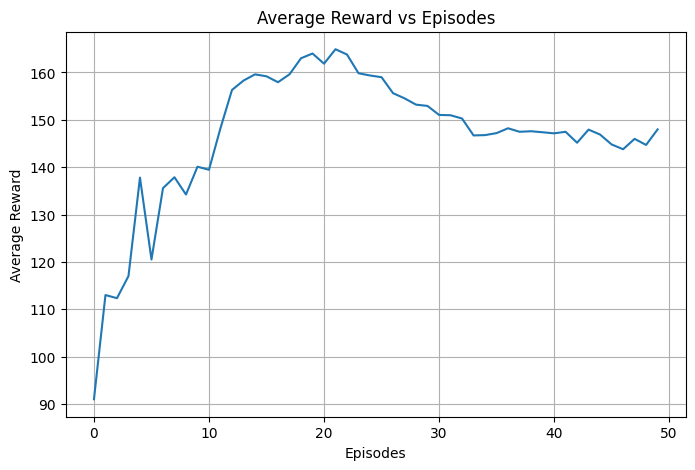

In [7]:
avg_rewards = []

for i in range(len(rewards)):
    avg_rewards.append(np.mean(rewards[:i+1]))

plt.figure(figsize=(8,5))
plt.plot(avg_rewards)

plt.title("Average Reward vs Episodes")
plt.xlabel("Episodes")
plt.ylabel("Average Reward")
plt.grid()

plt.savefig("reward_plot.png")
plt.show()